In [1]:
import sys
import os
import pandas as pd


sys.path.append(os.path.abspath('..')) # Go up one level to the project root and add it to the path
from src.utils.config import get_data_path, PROJECT_ROOT
from src.utils.viz import plot_zip_population_pivot

# snippet to skip a cell using %%skip TRUE
from IPython.core.magic import register_cell_magic
from IPython import get_ipython

@register_cell_magic
def skip(line, cell):
    # If the line says 'True', we skip. Otherwise, we run it.
    should_skip = eval(line) if line else True
    
    if should_skip:
        print("Cell skipped.")
        return
    else:
        get_ipython().run_cell(cell)

## SaTScan Required Variables

#### 1. Case File

| Variable | Description | Requirement |
| --- | --- | --- |
| **Location ID** | e.g., FIPS, ZIP | Required |
| **Number of Cases** | e.g., 1 | Required |
| **Date** | Event timeline | Required |
| **Age Group** | For stratification | Optional |

---

#### 2. Population File

> *Note: Required for Poisson model; skip if using Space-Time Permutation.*

| Variable | Description | Requirement |
| --- | --- | --- |
| **Location ID** | FIPS | Required |
| **Year** | Timeline | Required |
| **Population Count** | Total count | Required |
| **Age Group** | Must match Case File | Optional |

---

#### 3. Coordinates File

| Variable | Description | Requirement |
| --- | --- | --- |
| **Location ID** | FIPS | Required |
| **Latitude** | Or X coordinate | Required |
| **Longitude** | Or Y coordinate | Required |

---

#### NOTE:
ZCTAs (ZIP Code Tabulation Areas): the Census Bureau's geographic approximations of ZIP codes

## 1. Case File 
NVDRS dataset 2023 `keyes_973_nvdrs_2023.csv`
It already contains all the required variables

## 2. Popultation File 

### Resolving 2010-2011 Denominator Shocks

**Observation:** Calculating the year-over-year percentage change between the 2010 Decennial headcount and the 2011 ACS 5-Year estimates reveals over 2,000 ZIP codes with massive, artifactual population swings (many exceeding 70-100% variance). 

**The Cause:** These artifacts are heavily concentrated in areas with Group Quarters (military bases, universities, prisons). The 2010 Decennial Census executed an exact, single-day headcount of these facilities. The ACS, however, relies on continuous rolling samples and historically struggles to capture group quarters accurately. Mixing a precise 1-day count (2010) with a 60-month rolling average (2011) creates a severe structural break in the denominator. 

**Resolution:** To prevent these artificial denominator drops from triggering false-positive spatial clusters in the SaTScan Poisson model, we will drop the 2010 Decennial data. Instead, we will backfill 2010 using the 2011 ACS 5-Year estimates. Because the 2011 ACS represents survey data collected from 2007–2011, it mathematically covers 2010 and maintains standard errors consistently across our time series.

### Harmonizing Spatiotemporal Boundaries (2010-2019 to 2020 ZCTAs)

The U.S. Census Bureau redraws ZIP Code Tabulation Area (ZCTA) boundaries every 10 years. Between 2019 and 2020, many ZCTAs were split, merged, or eliminated. If we feed unadjusted pre-2020 population data into SaTScan alongside post-2020 data, the Poisson model will interpret these boundary redraws as sudden demographic shifts. A ZCTA shrinking in landmass would show an artificial population drop, which SaTScan would misinterpret as a massive spike in the suicide rate, triggering a false-positive space-time cluster.

We must project all 2010-2019 population estimates into the modern 2020 ZCTA boundaries. 

1. We use the **Official 2010 to 2020 ZCTA Relationship File** (`tab20_zcta510_zcta520_natl.txt`).
2. We calculate an **Allocation Factor (AF)** for every boundary intersection by dividing the shared land area (`AREALAND_PART`) by the total land area of the original 2010 ZCTA (`AREALAND_ZCTA5_10`).
3. We multiply the 2010-2019 ZCTA populations by this factor and re-aggregate them under the new 2020 ZCTA (`GEOID_ZCTA5_20`) identifiers.

***Variables used to harmonize:***
| Variable | Description |
| --- | --- |
| **GEOID_ZCTA5_10** | Geographic Identifier for the 2010 ZCTA (the old 5-digit ZIP code used for merging historical data). |
| **GEOID_ZCTA5_20** | Geographic Identifier for the 2020 ZCTA (the new 5-digit ZIP code used for the final aggregation). |
| **AREALAND_ZCTA5_10** | Total land area of the 2010 ZCTA. Used as the denominator to calculate the Allocation Factor. |
| **AREALAND_PART** | Land area of the geographic intersection between the 2010 and 2020 ZCTAs. Used as the numerator to calculate the Allocation Factor. |

## 3. Coordinates File - ZCTA
#### Gazetteer latitude and longitude for ZIP codes for midpoint (2022)
ZCTA boundaries change rarely (mostly during the decennial census). Even if a boundary slightly adjusts, the shift in the centroid is microscopic compared to the radius of a spatiotemporal cluster. Will use the midpoint year coordinates for the whole period.

https://www.census.gov/geographies/reference-files/time-series/geo/gazetteer-files.html

In [2]:
#TODO comapre pop_zip and pop_zip_c to verify that the armonizaion do something

## Execute SaTScan GUI data preparation Pipeline:

In [14]:
%%skip True #run only once

# ==========================================
# EXECUTE SATSCAN DATA PREPARATION PIPELINE
# ==========================================
from src.geospatial.prep_satscan import prep_satscan_gui

# 1. Define minimum required NVDRS columns (plus basic demographics)
#nvdrs_head = load_nvdrs(file_key="nvdrs", data_folder="raw", nrows=10000 )
nvdrs_columns = [
    'IncidentID', 
    'DeathDate', 
    'InjuryZip', 
    'ResidenceZip', 
    'IncidentCategory_c', 
    'PersonType', 
    'Sex', 
    'AgeYears_c'
]

# 2. Define Census ACS variables to fetch (ZCTA identifier and Total Population)
# WARNING: these two are the one that do not change name over time; age group population vars do change. 
#           
population_variables = {
    "NAME": "ZTCA5", 
    "DP05_0001E": "Population"
}

# 3. Define the year range for ACS data (2011 to 2023)
# Note: 2010 is handled internally by backfilling 2011 to avoid API shocks
population_years = range(2011, 2024)

# 4. Generate the Case, Population, and Coordinates CSVs
prep_satscan_gui(
    nvdrs_cols=nvdrs_columns,
    pop_vars=population_variables,
    pop_years=population_years
)

Preparing SaTScan files...
Processing Case Data...
Processing Population Data...
Processing Coordinates Data...
Success! Files ready for SaTScan GUI in: /Users/matteoperini/Library/CloudStorage/Box-Box/Matteo Perini/6_SuicideProj/CODE/suicide_forecasting/data/processed/satscan


#### Check population of the ZIPs with most cases:

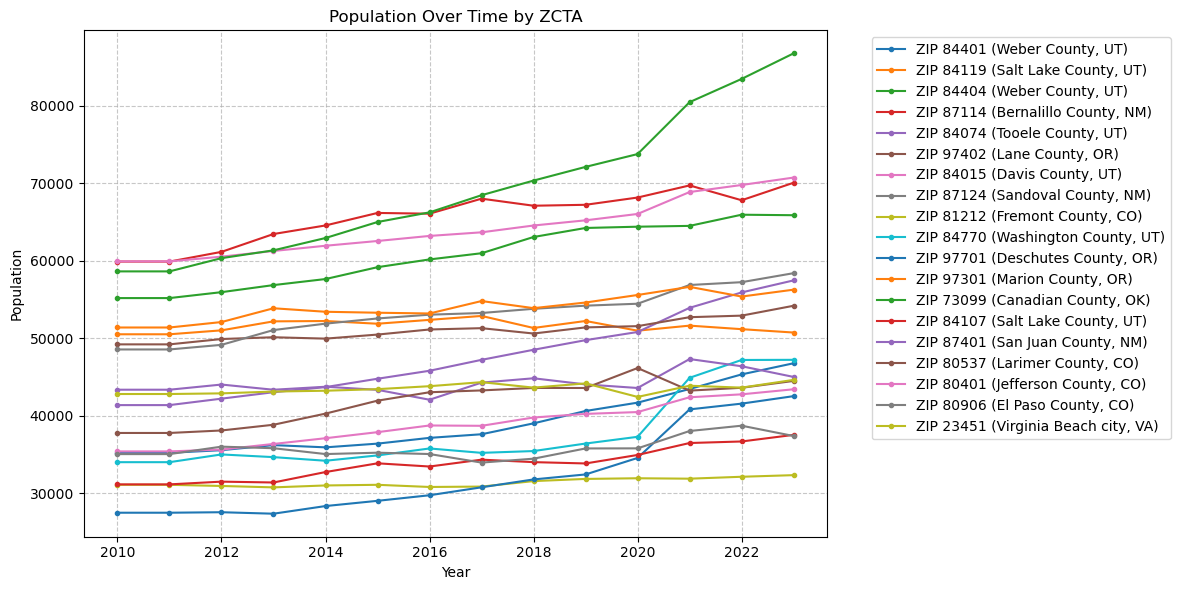

ZIP
99999    411
84401    218
84119    187
84404    186
87114    180
84074    178
97402    177
84015    177
87124    177
81212    176
84770    172
97701    172
97301    171
73099    168
84107    163
87401    160
80537    157
80401    155
80906    154
23451    152
Name: count, dtype: int64

In [4]:
### PLOTTING THE ZIP WITH THE MOST CASES
pop_file = PROJECT_ROOT / "data" / "processed" / "satscan" / "satscan_population.csv"
cases_file = PROJECT_ROOT / "data" / "processed" / "satscan" / "satscan_cases_enriched.csv"

pop_satscan = pd.read_csv(pop_file, dtype={'ZIP': str})
nvdrs_satscan = pd.read_csv(cases_file, dtype={'ZIP': str})


# 2. Load the state/county mapping
map_path = get_data_path("zip_to_state_county")
zip_mapping = pd.read_csv(map_path, dtype={'ZIP': str})

# 3. Merge to recover state and county labels
pop_zip_c = pop_satscan.merge(zip_mapping, on='ZIP', how='left')

# Create the aggregated pivot table 
pop_pivot_check = pop_zip_c.pivot_table(index='ZIP', columns='Year', values='Population', aggfunc='sum')
# Reset the index so ZIP is a standard column
pop_pivot_check = pop_pivot_check.reset_index()
# Merge with a unique ZIP mapping to add state and county names
zip_mapping = pop_zip_c[['ZIP', 'state', 'county']].drop_duplicates(subset=['ZIP'])
pop_pivot_check = zip_mapping.merge(pop_pivot_check, on='ZIP', how='right')

#Calculate the percentage change across the boundary redraw (2019 to 2021)
pop_pivot_check['Jump_19_21'] = ((pop_pivot_check[2021] - pop_pivot_check[2019]) / pop_pivot_check[2019]) * 100
# 1. Get counts of each ZIP
nvdrs_zip_counts = nvdrs_satscan['ZIP'].value_counts()

# 2. Filter for ZIPs with a count of min_cases or more, then convert to a list
min_cases = 3
nvdrs_s_zips = nvdrs_zip_counts[nvdrs_zip_counts >= min_cases].index.tolist()

##### SELECT ONLY ZIPS wit more than min_case in NVDRS (see above)
nvdrs_pop_pivot_check = pop_pivot_check[pop_pivot_check['ZIP'].isin(nvdrs_s_zips)]
# Filter out small-number noise (base population < 1000)
nvdrs_pop_pivot_check = nvdrs_pop_pivot_check[~((nvdrs_pop_pivot_check[2019] < 1000) | (nvdrs_pop_pivot_check[2021] < 1000))].copy()

# 2. Filter for ZIPs with a count of min_cases or more, then convert to a list
min_cases = 3
nvdrs_s_zips = nvdrs_zip_counts[nvdrs_zip_counts >= min_cases].index.tolist()
most_cases_zip = nvdrs_zip_counts.head(20).index.tolist()

plot_zip_population_pivot(nvdrs_pop_pivot_check,most_cases_zip ,county_col='county',state_col='state')
nvdrs_zip_counts.head(20)


#### Check worse ZIP population Changes:

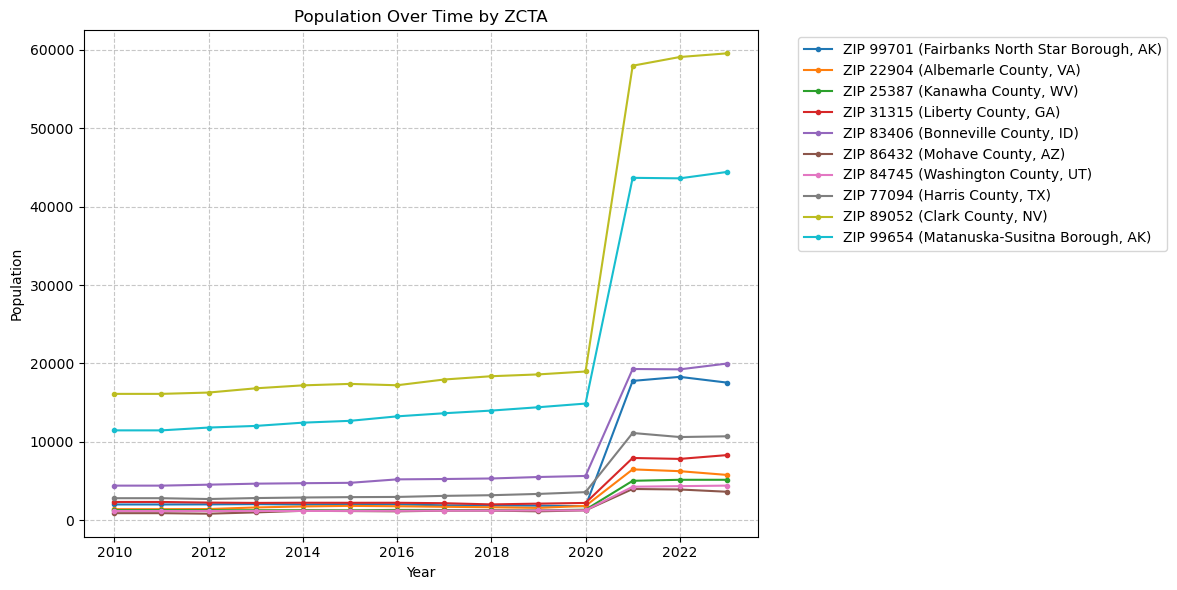

Top 20 Largest 2019-2021 Population Jumps:


,ZIP,state,county,Jump_19_21,2019,2020,2021
33671,99701,AK,Fairbanks North Star Borough,847.814499,1876.0,1804.0,17781.0
7086,22904,VA,Albemarle County,309.577820,1587.0,1845.0,6500.0
8002,25387,WV,Kanawha County,294.600939,1278.0,1358.0,5043.0
10285,31315,GA,Liberty County,272.808251,2133.0,2221.0,7952.0
29142,83406,ID,Bonneville County,249.203764,5526.0,5662.0,19297.0
30012,86432,AZ,Mohave County,247.826087,1150.0,1274.0,4000.0
29593,84745,UT,Washington County,238.546603,1266.0,1276.0,4286.0
27267,77094,TX,Harris County,230.436072,3371.0,3597.0,11139.0


In [5]:
# Display the top 20 worst offenders
nvdrs_pop_pivot_check['Jump_19_21_abs'] = abs(nvdrs_pop_pivot_check['Jump_19_21'])
nvdrs_pop_pivot_check = nvdrs_pop_pivot_check.sort_values(by='Jump_19_21', key=abs, ascending=False)

# Grab the top 5 ZIP strings to feed into your plotting function
nvdr_zips_to_test = nvdrs_pop_pivot_check.head(10)['ZIP'].tolist()
plot_zip_population_pivot(nvdrs_pop_pivot_check,nvdr_zips_to_test,county_col='county',state_col='state')

print("Top 20 Largest 2019-2021 Population Jumps:")
nvdrs_pop_pivot_check.loc[nvdrs_pop_pivot_check.index, ['ZIP','state', 'county','Jump_19_21', 2019, 2020, 2021,]].head(8)

### Check the ZIP population change distributiion:

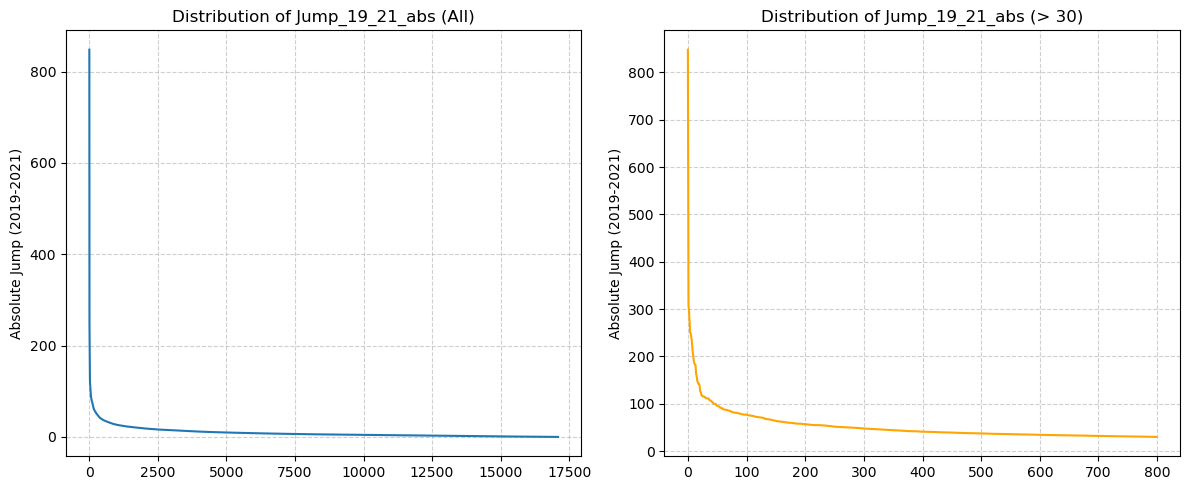

In [ ]:
%%skip True
# select only the zips that changed more than 30% from 19 to 21
import matplotlib.pyplot as plt

nvdrs_pop_pivot_check_large = nvdrs_pop_pivot_check[nvdrs_pop_pivot_check['Jump_19_21_abs'] > 30]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First plot: All data
axes[0].plot(nvdrs_pop_pivot_check['Jump_19_21_abs'].reset_index(drop=True))
axes[0].set_title('Distribution of Jump_19_21_abs (All)')
axes[0].set_ylabel('Absolute Jump (2019-2021)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Second plot: Filtered data (> 30)
axes[1].plot(nvdrs_pop_pivot_check_large['Jump_19_21_abs'].reset_index(drop=True), color='orange')
axes[1].set_title('Distribution of Jump_19_21_abs (> 30)')
axes[1].set_ylabel('Absolute Jump (2019-2021)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

#### CHECK THE NAME OF THE CENSUS VARIBALES YEAR BY YEAR:

In [ ]:
%%skip True

# -> var names for age groups population at zip level varies, and the meaning on the var varies
# ----> "NAME": "ZTCA5" and "DP05_0001E": "Population" remains the same, these are the one we use
import requests
import re
years_to_fetch=range(2010,2024)
vars_to_fetch = {
    "NAME": "ZTCA5",
    "DP05_0001E": "Population",
    "DP05_0005E": "Pop_<5",
    "DP05_0006E": "Pop_5-9",
    "DP05_0007E": "Pop_10-14",
    "DP05_0008E": "Pop_15-19",
    "DP05_0009E": "Pop_20-24",
    "DP05_0010E": "Pop_25-34",
    "DP05_0011E": "Pop_35-44",
    "DP05_0012E": "Pop_45-54",
    "DP05_0013E": "Pop_55-59",
    "DP05_0014E": "Pop_60-64",
    "DP05_0015E": "Pop_65-74",
    "DP05_0016E": "Pop_75-84",
    "DP05_0017E": "Pop_85+"
}

def get_profile_label_map(year: int, group: str, dataset: str = "acs5") -> dict:
    """{label: code} for one ACS Data Profile group/year, estimates only."""
    url = f"https://api.census.gov/data/{year}/acs/{dataset}/profile/groups/{group}.json"
    resp = requests.get(url)
    resp.raise_for_status()
    variables = resp.json()["variables"]
    return {v["label"]: code for code, v in variables.items() if re.match(r"^DP\d{2}_\d+E$", code)}

# Does DP05_0037E etc. mean the same thing every year you're pulling?
for year in years_to_fetch:
    code_to_label = {v: k for k, v in get_profile_label_map(year, "DP05").items()}
    print(year, {c: code_to_label.get(c, "MISSING/CHANGED") for c in vars_to_fetch if c != "NAME"})

2010 {'DP05_0001E': 'Estimate!!SEX AND AGE!!Total population', 'DP05_0005E': 'Estimate!!SEX AND AGE!!5 to 9 years', 'DP05_0006E': 'Estimate!!SEX AND AGE!!10 to 14 years', 'DP05_0007E': 'Estimate!!SEX AND AGE!!15 to 19 years', 'DP05_0008E': 'Estimate!!SEX AND AGE!!20 to 24 years', 'DP05_0009E': 'Estimate!!SEX AND AGE!!25 to 34 years', 'DP05_0010E': 'Estimate!!SEX AND AGE!!35 to 44 years', 'DP05_0011E': 'Estimate!!SEX AND AGE!!45 to 54 years', 'DP05_0012E': 'Estimate!!SEX AND AGE!!55 to 59 years', 'DP05_0013E': 'Estimate!!SEX AND AGE!!60 to 64 years', 'DP05_0014E': 'Estimate!!SEX AND AGE!!65 to 74 years', 'DP05_0015E': 'Estimate!!SEX AND AGE!!75 to 84 years', 'DP05_0016E': 'Estimate!!SEX AND AGE!!85 years and over', 'DP05_0017E': 'Estimate!!SEX AND AGE!!Median age (years)'}
2011 {'DP05_0001E': 'Estimate!!SEX AND AGE!!Total population', 'DP05_0005E': 'Estimate!!SEX AND AGE!!5 to 9 years', 'DP05_0006E': 'Estimate!!SEX AND AGE!!10 to 14 years', 'DP05_0007E': 'Estimate!!SEX AND AGE!!15 to 19

### JUSTIFY DROPPING THE 2010 DECENNIAL CENSUS:

In [ ]:
%%skip True

# Mixing a 1-day headcount (2010 Decennial) with a 60-month rolling average (2011 ACS) 
# creates severe denominator shocks, especially in Group Quarters. 
# This block demonstrates the artifacts created by mixing the two APIs.

from src.etl.ingest import fetch_2010_decennial_population, fetch_census
from src.etl.transform import calc_pct_change
import pandas as pd

# 1. Fetch the exact Decennial count
decennial_2010 = fetch_2010_decennial_population()

# 2. Fetch the rolling ACS counts
acs_2011_2012 = fetch_census({"NAME": "ZTCA5", "DP05_0001E": "Population"}, range(2011, 2013), geo_level="zip")
acs_2011_2012.rename(columns={"zip code tabulation area": "ZIP"}, inplace=True)

# 3. Combine and Pivot
pop_compare = pd.concat([decennial_2010, acs_2011_2012], ignore_index=True)
pop_compare['Population'] = pd.to_numeric(pop_compare['Population'], errors='coerce')
pop_pivot = pop_compare.pivot(index='ZIP', columns='Year', values='Population')

# 4. Calculate the shock
pop_pivot['Jump_10_11_pct'] = calc_pct_change(pop_pivot, 2010, 2011)

# 5. Display the worst artifacts (ZIPs with > 1000 people and > 30% artificial jump)
artifacts = pop_pivot[(pop_pivot['Jump_10_11_pct'].abs() > 30) & (pop_pivot[2010] > 1000)]
print(f"Found {len(artifacts)} ZIPs with massive artificial population swings due to the API switch.")
print(artifacts[[2010, 2011, 'Jump_10_11_pct']].sort_values(by='Jump_10_11_pct', key=abs, ascending=False).head(10))

Found 362 ZIPs with massive artificial population swings due to the API switch.
Year   2010  2011  Jump_10_11_pct
ZIP                              
89018  1007  5897      485.600794
23511  2457  6858      179.120879
55455  1050  2107      100.666667
08320  1256     0     -100.000000
98421  1308    24      -98.165138
24430  2643  4997       89.065456
17887  1778   328      -81.552306
76597  2882   553      -80.811936
27503  3471  6242       79.832901
72035  1083  1932       78.393352


### Compare 2020 ACTUAL POP COUNTS from census vs 2020 1-year rolling window counts form ACS5:
the general decennal census reports the actual counts at the day of the census. it might differ form the 1-year rolling window population count usied by the ACS5 that sample the part of the population continusly.

the follwing commands show the fluctuations, that's why we use the ACS5 counts in the analysis

In [ ]:
%%skip True

# download the 2010 ACTUAL COUNTS in a given day (not the 1 year rolling window of ACS)
# from a different api link - the decennal census

from src.etl.ingest import fetch_2010_decennial_population, fetch_census
from src.etl.transform import calc_pct_change
import pandas as pd


# Fetch 2010 Decennial data and append to pop_zip
df_2010 = fetch_2010_decennial_population()


# Fetch 2011-2023 ACS5 1-year estiames
vars_to_fetch = {
    "NAME": "ZTCA5",
    "DP05_0001E": "Population"
}
years_to_fetch = range(2011, 2024) # range goes to 2023
pop_zip = fetch_census(vars_to_fetch, years_to_fetch, geo_level="zip")
pop_zip.rename(columns={"zip code tabulation area": "ZIP"}, inplace=True)
pop_zip = pop_zip.drop('state', axis=1) # will add state name and county name later
# population to numeric
pop_zip['Population'] = pd.to_numeric(pop_zip['Population'], errors='coerce') 

pop_zip = pd.concat([df_2010, pop_zip], ignore_index=True)

# Pivot data so years become columns for easy comparison
pop_pivot = pop_zip.pivot(index='ZIP', columns='Year', values='Population')

# ADD STATE AND COUNTY TO ZIP 
# -----> Approximation: some ZIPs crosses state and county lines. the major one indicated here, use just for lables

map_path = get_data_path("zip_to_state_county")
zip_mapping = pd.read_csv(map_path, dtype={'ZIP': str})

# Ensure target column is string for a safe merge, then merge
pop_pivot.index = pop_pivot.index.astype(str)
pop_pivot = pop_pivot.merge(zip_mapping, left_index=True, right_on='ZIP', how='left')


# Calculate Year-over-Year fluctuations
pop_pivot['pct_change_10_11'] = calc_pct_change(pop_pivot, 2010, 2011)
pop_pivot['pct_change_11_12'] = calc_pct_change(pop_pivot, 2011, 2012)
pop_pivot['pct_change_12_13'] = calc_pct_change(pop_pivot, 2012, 2013)

# Filter for suspect fluctuations 
threshold_pct = 15
min_pop = 1000

suspect_10_11 = pop_pivot[(pop_pivot['pct_change_10_11'].abs() > threshold_pct) & (pop_pivot[2010] > min_pop)]
suspect_11_12 = pop_pivot[(pop_pivot['pct_change_11_12'].abs() > threshold_pct) & (pop_pivot[2011] > min_pop)]
suspect_12_13 = pop_pivot[(pop_pivot['pct_change_12_13'].abs() > threshold_pct) & (pop_pivot[2012] > min_pop)]

# Review the damage
print(f"Artifacts 2010-2011: {len(suspect_10_11)} ZIPs")
print(f"Artifacts 2011-2012: {len(suspect_11_12)} ZIPs")
print(f"Artifacts 2012-2013: {len(suspect_12_13)} ZIPs")

print("\nTop 10 Largest Fluctuations (2010 to 2011):")
suspect_10_11[[2010, 2011, 'pct_change_10_11', 'county', 'state']].sort_values(by='pct_change_10_11', ascending=False).head(10)

Artifacts 2010-2011: 2088 ZIPs
Artifacts 2011-2012: 625 ZIPs
Artifacts 2012-2013: 636 ZIPs

Top 10 Largest Fluctuations (2010 to 2011):


,2010,2011,pct_change_10_11,county,state
27965,1007.0,5897.0,485.600794,Clark County,NV
42625,2457.0,6858.0,179.120879,Norfolk city,VA
14414,1050.0,2107.0,100.666667,Hennepin County,MN
282,2643.0,4997.0,89.065456,Augusta County,VA
1474,3471.0,6242.0,79.832901,Durham County,NC
21458,1083.0,1932.0,78.393352,Faulkner County,AR
13609,1610.0,2838.0,76.273292,Adams County,WI
1538,3049.0,5316.0,74.352247,Granville County,NC
35735,2371.0,4101.0,72.964994,Atlantic County,NJ
29934,3793.0,6549.0,72.660163,Solano County,CA
